In [1]:
import pandas as pd
import os

import tensorflow as tf
import tensorflow as tf
tf.config.set_visible_devices([], "GPU")  # ✅ désactive le GPU

# Charger le CSV
df = pd.read_csv("../data/dataset_selection_sans_leger.csv")

# Aperçu du dataset
print("Aperçu du dataset :")
print(df.head())

print("\nInformations générales :")
print(df.info())


2026-02-28 22:45:16.896140: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Aperçu du dataset :
                                                path     label
0  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
1  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tra...  glaucome
2  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tes...  glaucome
3  /home/mathis/Memoire/data/glaucome/ORIGA/ORIGA...  glaucome
4  /home/mathis/Memoire/data/glaucome/LAG/LAG/Tes...  glaucome

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6208 entries, 0 to 6207
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   path    6208 non-null   object
 1   label   6208 non-null   object
dtypes: object(2)
memory usage: 97.1+ KB
None


In [2]:
print(f"Nombre total d'images : {len(df)}")
print(f"Nombre de colonnes : {df.shape[1]}")


Nombre total d'images : 6208
Nombre de colonnes : 2


In [3]:
# Compter le nombre d'images par label
class_counts = df['label'].value_counts()

print("\nRépartition des labels :")
print(class_counts)

# Pourcentage par label
class_percent = df['label'].value_counts(normalize=True) * 100
print("\nPourcentage par label :")
print(class_percent.round(2))



Répartition des labels :
label
glaucome    1552
mda         1552
diabete     1552
normaux     1552
Name: count, dtype: int64

Pourcentage par label :
label
glaucome    25.0
mda         25.0
diabete     25.0
normaux     25.0
Name: proportion, dtype: float64


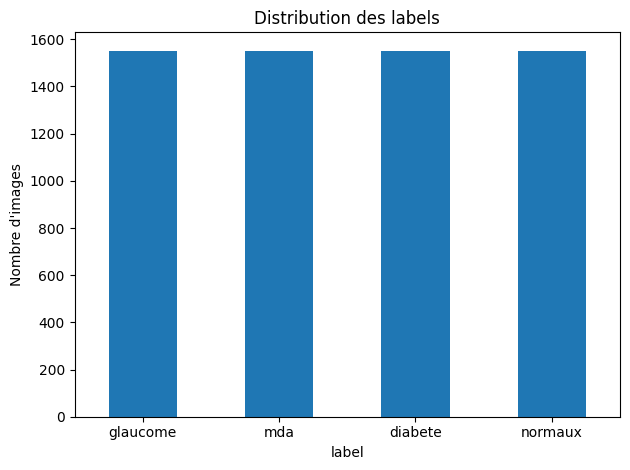

In [4]:
import matplotlib.pyplot as plt

class_counts.plot(kind='bar')
plt.title("Distribution des labels")
plt.xlabel("label")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [5]:
for classe in df['label'].unique():
    print(f"\nExemples pour la classe '{classe}' :")
    print(df[df['label'] == classe]['path'].head(3).tolist())



Exemples pour la classe 'glaucome' :
['/home/mathis/Memoire/data/glaucome/LAG/LAG/Training/glaucoma/1308.jpg', '/home/mathis/Memoire/data/glaucome/LAG/LAG/Training/glaucoma/1456.jpg', '/home/mathis/Memoire/data/glaucome/LAG/LAG/Testing/glaucoma/4275.jpg']

Exemples pour la classe 'mda' :
['/home/mathis/Memoire/data/mda/Fundus/Fundus/ARMD/161.png', '/home/mathis/Memoire/data/mda/Fundus/Fundus/ARMD/328.png', '/home/mathis/Memoire/data/mda/Fundus/Fundus/ARMD/235.png']

Exemples pour la classe 'diabete' :
['/home/mathis/Memoire/data/diabete/train.zip/train/25985_right.jpeg', '/home/mathis/Memoire/data/diabete/train.zip/train/38016_right.jpeg', '/home/mathis/Memoire/data/diabete/train.zip/train/20574_left.jpeg']

Exemples pour la classe 'normaux' :
['/home/mathis/Memoire/data/mda/ODIR-5K/ODIR-5K/Training Images/2457_right.jpg', '/home/mathis/Memoire/data/diabete/train.zip/train/30306_left.jpeg', '/home/mathis/Memoire/data/diabete/train.zip/train/3710_left.jpeg']


In [6]:
from sklearn.model_selection import train_test_split

df_train, df_temp = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

df_test, df_val = train_test_split(
    df_temp,
    test_size=0.5,
    stratify=df_temp['label'],
    random_state=42
)

print("Tailles des splits :")
print(f"Train : {len(df_train)}")
print(f"Test : {len(df_test)}")
print(f"Validation : {len(df_val)}")

Tailles des splits :
Train : 4966
Test : 621
Validation : 621


In [7]:
def show_distribution(name, data):
    print(f"\n{name}")
    print(data['label'].value_counts(normalize=True).round(3))

show_distribution("Train", df_train)
show_distribution("Test", df_test)
show_distribution("Validation", df_val)



Train
label
glaucome    0.25
normaux     0.25
mda         0.25
diabete     0.25
Name: proportion, dtype: float64

Test
label
mda         0.251
glaucome    0.250
diabete     0.250
normaux     0.250
Name: proportion, dtype: float64

Validation
label
diabete     0.251
glaucome    0.250
normaux     0.250
mda         0.250
Name: proportion, dtype: float64


In [8]:
import numpy as np

IMG_SIZE = (256, 256)
BATCH_SIZE = 32
SEED = 42

# mapping label -> id (si label est texte)
classes = sorted(df_train["label"].unique().tolist())
label_to_id = {c:i for i,c in enumerate(classes)}

def df_to_ds(df, shuffle=False):
    paths = df["path"].astype(str).values
    labels = df["label"].map(label_to_id).astype(int).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)

    def load_and_preprocess(path, label):
        img_bytes = tf.io.read_file(path)
        img = tf.image.decode_image(img_bytes, channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32)
        return img, label

    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    # ✅ ignore les fichiers qui cassent decode_image
    ds = ds.apply(tf.data.experimental.ignore_errors())

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = df_to_ds(df_train, shuffle=True)
val_ds   = df_to_ds(df_val, shuffle=False)
test_ds  = df_to_ds(df_test, shuffle=False)


Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


In [9]:
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="aug")

#cnn
model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(256, 256, 3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(df['label'].unique()), activation='softmax')
])


early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
tf.config.optimizer.set_jit(False)   # désactive XLA globalement

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
    run_eagerly=True,   # ✅ évite graph/JIT => stoppe adam/Pow_* qui casse
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50


/home/mathis/Memoire/.venv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    156/Unknown 114s 727ms/step - accuracy: 0.5173 - loss: 1.1922

2026-02-28 22:47:15.725141: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/home/mathis/Memoire/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


156/156 ━━━━━━━━━━━━━━━━━━━━ 118s 756ms/step - accuracy: 0.5785 - loss: 0.9675 - val_accuracy: 0.6457 - val_loss: 0.8487
Epoch 2/50


...

156/156 ━━━━━━━━━━━━━━━━━━━━ 116s 743ms/step - accuracy: 0.6665 - loss: 0.7480 - val_accuracy: 0.7198 - val_loss: 0.6932
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 115s 734ms/step - accuracy: 0.6911 - loss: 0.6851 - val_accuracy: 0.6506 - val_loss: 0.7557
Epoch 5/50


2026-02-28 22:53:04.564334: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


156/156 ━━━━━━━━━━━━━━━━━━━━ 114s 732ms/step - accuracy: 0.6969 - loss: 0.6699 - val_accuracy: 0.7311 - val_loss: 0.6216
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 116s 745ms/step - accuracy: 0.7074 - loss: 0.6416 - val_accuracy: 0.6602 - val_loss: 0.7324
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 116s 743ms/step - accuracy: 0.7167 - loss: 0.6228 - val_accuracy: 0.7118 - val_loss: 0.6557
Epoch 8/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 114s 731ms/step - accuracy: 0.7231 - loss: 0.6028 - val_accuracy: 0.7552 - val_loss: 0.5854
Epoch 9/50


2026-02-28 23:00:45.597005: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


156/156 ━━━━━━━━━━━━━━━━━━━━ 119s 764ms/step - accuracy: 0.7308 - loss: 0.5842 - val_accuracy: 0.7504 - val_loss: 0.6020
Epoch 10/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 122s 779ms/step - accuracy: 0.7427 - loss: 0.5714 - val_accuracy: 0.7504 - val_loss: 0.6076
Epoch 11/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 121s 776ms/step - accuracy: 0.7489 - loss: 0.5624 - val_accuracy: 0.7198 - val_loss: 0.5991
Epoch 12/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 123s 790ms/step - accuracy: 0.7527 - loss: 0.5522 - val_accuracy: 0.7262 - val_loss: 0.6044
Epoch 13/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 124s 797ms/step - accuracy: 0.7547 - loss: 0.5465 - val_accuracy: 0.7391 - val_loss: 0.5965



=== Scores globaux ===
Accuracy            : 0.7665
Balanced accuracy   : 0.7663
Precision (macro)   : 0.7563
Recall (macro)      : 0.7663
F1 (macro)          : 0.7538
Precision (weighted): 0.7564
Recall (weighted)   : 0.7665
F1 (weighted)       : 0.7540

=== Rapport par classe ===
              precision    recall  f1-score   support

     diabete       0.72      0.89      0.79       155
    glaucome       0.90      0.85      0.88       155
         mda       0.82      0.92      0.86       156
     normaux       0.59      0.41      0.48       155

    accuracy                           0.77       621
   macro avg       0.76      0.77      0.75       621
weighted avg       0.76      0.77      0.75       621



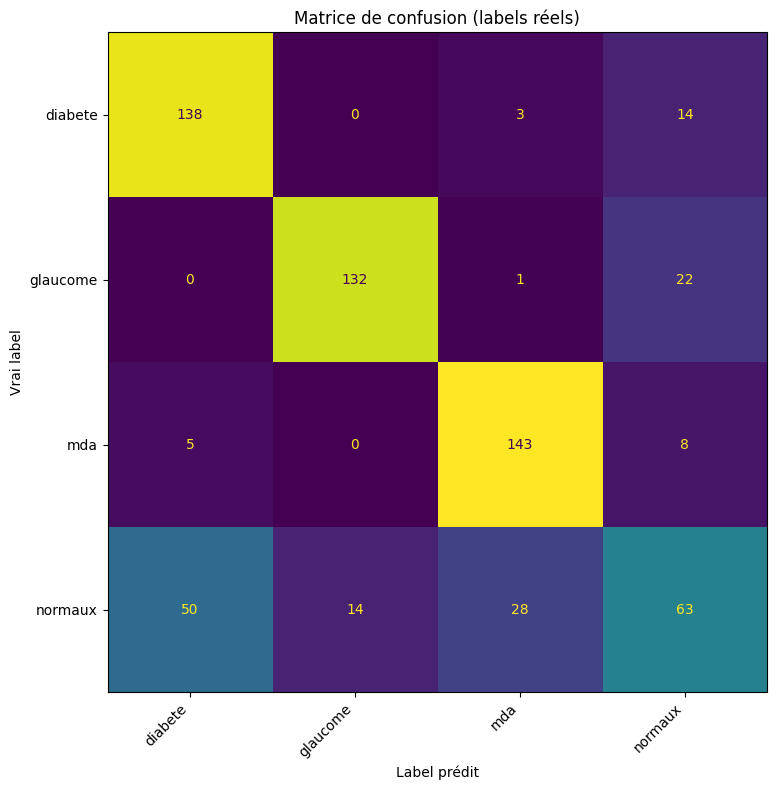

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report
)
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

proba = model.predict(test_ds, verbose=0)
y_pred = np.argmax(proba, axis=1)
num_classes = len(classes)

# ----------------------------
# 7) METRICS
# ----------------------------
acc = accuracy_score(y_true, y_pred)
bacc = balanced_accuracy_score(y_true, y_pred)

prec_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec_macro  = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro   = f1_score(y_true, y_pred, average="macro", zero_division=0)

prec_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
rec_weighted  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1_weighted   = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("\n=== Scores globaux ===")
print(f"Accuracy            : {acc:.4f}")
print(f"Balanced accuracy   : {bacc:.4f}")
print(f"Precision (macro)   : {prec_macro:.4f}")
print(f"Recall (macro)      : {rec_macro:.4f}")
print(f"F1 (macro)          : {f1_macro:.4f}")
print(f"Precision (weighted): {prec_weighted:.4f}")
print(f"Recall (weighted)   : {rec_weighted:.4f}")
print(f"F1 (weighted)       : {f1_weighted:.4f}")

print("\n=== Rapport par classe ===")
print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

# ----------------------------
# 8) CONFUSION MATRIX (labels réels, ordre forcé)
# ----------------------------
label_indices = list(range(num_classes))
cm = confusion_matrix(y_true, y_pred, labels=label_indices)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, values_format="d", cmap=None, colorbar=False)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.xlabel("Label prédit")
plt.ylabel("Vrai label")
plt.title("Matrice de confusion (labels réels)")
plt.tight_layout()
plt.show()


In [11]:
import numpy as np
from PIL import Image
def crop_black_border_pil(img: Image.Image, thr=10, pad=10):
    """
    img: PIL RGB
    thr: seuil (0-255). Plus haut => enlève plus (attention à ne pas rogner l'image utile)
    pad: marge ajoutée autour du crop
    """
    arr = np.array(img)  # H,W,3 uint8
    gray = arr.mean(axis=2)  # H,W

    mask = gray > thr  # True = zone utile
    if not mask.any():
        return img  # image totalement sombre -> on ne touche pas

    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()

    # padding + clamp aux bords
    y0 = max(0, y0 - pad)
    x0 = max(0, x0 - pad)
    y1 = min(arr.shape[0] - 1, y1 + pad)
    x1 = min(arr.shape[1] - 1, x1 + pad)

    return img.crop((x0, y0, x1 + 1, y1 + 1))

In [12]:

def df_to_ds(df, shuffle=False):
    paths = df["path"].astype(str).values
    labels = df["label"].map(label_to_id).astype(int).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)

    def load_and_preprocess(path, label):
        def _py_load(p):
            p = p.numpy().decode("utf-8")
            img = Image.open(p).convert("RGB")
            img = crop_black_border_pil(img, thr=10, pad=10)
            img = img.resize(IMG_SIZE, Image.BILINEAR)
            return np.array(img, dtype=np.float32)

        img = tf.py_function(_py_load, [path], Tout=tf.float32)
        img.set_shape([256, 256, 3])  # shape fixe car resize déjà fait dans _py_load
        return img, label


    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    # ✅ ignore les fichiers qui cassent decode_image
    ds = ds.apply(tf.data.experimental.ignore_errors())

    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = df_to_ds(df_train, shuffle=True)
val_ds   = df_to_ds(df_val, shuffle=False)
test_ds  = df_to_ds(df_test, shuffle=False)

In [13]:
from tensorflow import keras
from tensorflow.keras import layers

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="aug")

#cnn
model = keras.Sequential([
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(256, 256, 3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(df['label'].unique()), activation='softmax')
])


early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
tf.config.optimizer.set_jit(False)   # désactive XLA globalement

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
    run_eagerly=True,   # ✅ évite graph/JIT => stoppe adam/Pow_* qui casse
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50


/home/mathis/Memoire/.venv/lib/python3.12/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


    156/Unknown 226s 1s/step - accuracy: 0.4862 - loss: 1.9599

/home/mathis/Memoire/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


156/156 ━━━━━━━━━━━━━━━━━━━━ 247s 2s/step - accuracy: 0.5707 - loss: 1.1886 - val_accuracy: 0.6554 - val_loss: 0.8643
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 239s 2s/step - accuracy: 0.6480 - loss: 0.8050 - val_accuracy: 0.6908 - val_loss: 0.7453
Epoch 3/50


2026-02-28 23:20:10.240845: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


156/156 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - accuracy: 0.6631 - loss: 0.7581 - val_accuracy: 0.6844 - val_loss: 0.7228
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.6903 - loss: 0.7041 - val_accuracy: 0.6828 - val_loss: 0.7190
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 240s 2s/step - accuracy: 0.7048 - loss: 0.6707 - val_accuracy: 0.7343 - val_loss: 0.6397
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.7191 - loss: 0.6440 - val_accuracy: 0.7005 - val_loss: 0.6966
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.7201 - loss: 0.6376 - val_accuracy: 0.7311 - val_loss: 0.6435
Epoch 8/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 241s 2s/step - accuracy: 0.7273 - loss: 0.6140 - val_accuracy: 0.7440 - val_loss: 0.5937
Epoch 9/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.7336 - loss: 0.6084 - val_accuracy: 0.7633 - val_loss: 0.6121
Epoch 10/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.7376 - loss: 0.5971 - val_accuracy: 0.75

2026-03-01 00:22:39.969048: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


156/156 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.7714 - loss: 0.5033 - val_accuracy: 0.7697 - val_loss: 0.5273



=== Scores globaux ===
Accuracy            : 0.7746
Balanced accuracy   : 0.7743
Precision (macro)   : 0.7634
Recall (macro)      : 0.7743
F1 (macro)          : 0.7564
Precision (weighted): 0.7635
Recall (weighted)   : 0.7746
F1 (weighted)       : 0.7565

=== Rapport par classe ===
              precision    recall  f1-score   support

     diabete       0.72      0.85      0.78       155
    glaucome       0.88      0.96      0.92       155
         mda       0.78      0.90      0.84       156
     normaux       0.67      0.39      0.49       155

    accuracy                           0.77       621
   macro avg       0.76      0.77      0.76       621
weighted avg       0.76      0.77      0.76       621



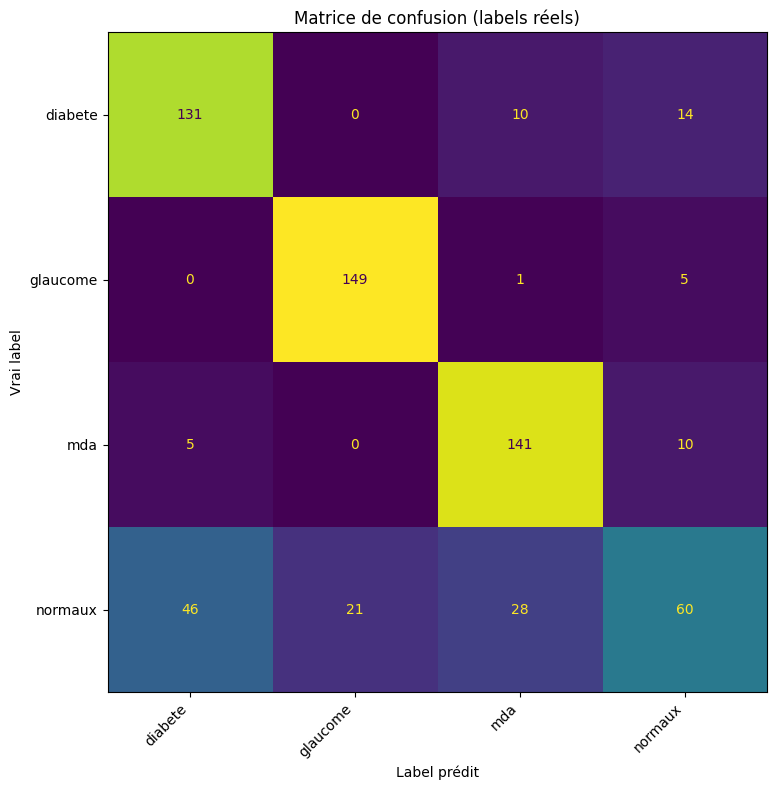

In [14]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report
)
y_true = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

proba = model.predict(test_ds, verbose=0)
y_pred = np.argmax(proba, axis=1)
num_classes = len(classes)

# ----------------------------
# 7) METRICS
# ----------------------------
acc = accuracy_score(y_true, y_pred)
bacc = balanced_accuracy_score(y_true, y_pred)

prec_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec_macro  = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro   = f1_score(y_true, y_pred, average="macro", zero_division=0)

prec_weighted = precision_score(y_true, y_pred, average="weighted", zero_division=0)
rec_weighted  = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1_weighted   = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print("\n=== Scores globaux ===")
print(f"Accuracy            : {acc:.4f}")
print(f"Balanced accuracy   : {bacc:.4f}")
print(f"Precision (macro)   : {prec_macro:.4f}")
print(f"Recall (macro)      : {rec_macro:.4f}")
print(f"F1 (macro)          : {f1_macro:.4f}")
print(f"Precision (weighted): {prec_weighted:.4f}")
print(f"Recall (weighted)   : {rec_weighted:.4f}")
print(f"F1 (weighted)       : {f1_weighted:.4f}")

print("\n=== Rapport par classe ===")
print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))

# ----------------------------
# 8) CONFUSION MATRIX (labels réels, ordre forcé)
# ----------------------------
label_indices = list(range(num_classes))
cm = confusion_matrix(y_true, y_pred, labels=label_indices)

fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, values_format="d", cmap=None, colorbar=False)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.xlabel("Label prédit")
plt.ylabel("Vrai label")
plt.title("Matrice de confusion (labels réels)")
plt.tight_layout()
plt.show()
